In [ ]:
import pandas as pd
import numpy as np
import cv2

In [ ]:
# 1. Load your image (ensure the filename matches your file)
image_path = 'image_2.png' 
img = cv2.imread(image_path)

if img is None:
    print(f"Error: Could not load image from {image_path}. Check the file path!")
else:
    # Create a window that can be resized (useful for high-res CCTV images)
    cv2.namedWindow("ROI Selector", cv2.WINDOW_NORMAL)
    
    print("INSTRUCTIONS:")
    print("1. Click and drag your mouse to draw a box around the TRAFFIC LIGHT.")
    print("2. Press 'ENTER' or 'SPACE' to confirm the selection.")
    print("3. Press 'C' to cancel or 'ESC' to exit.")

    # 2. Open the Interactive ROI Selector
    # showCrosshair=True helps you center the box exactly on the red light bulb
    roi = cv2.selectROI("ROI Selector", img, fromCenter=False, showCrosshair=True)

    # The 'roi' variable stores: (x_start, y_start, width, height)
    x, y, w, h = roi

    if w > 0 and h > 0:
        # 3. Crop the selected area to verify
        roi_cropped = img[int(y):int(y+h), int(x):int(x+w)]
        
        # Display the result
        cv2.imshow("Selected Traffic Light ROI", roi_cropped)
        
        print("\n--- ROI COORDINATES SAVED ---")
        print(f"X Start: {x}")
        print(f"Y Start: {y}")
        print(f"Width  : {w}")
        print(f"Height : {h}")
        print("------------------------------")
        print(f"In your main code, use: traffic_light_zone = frame[{y}:{y+h}, {x}:{x+w}]")
        
        cv2.waitKey(0)
    else:
        print("Selection cancelled.")

    cv2.destroyAllWindows()

In [ ]:
import cv2
import numpy as np

# 1. Load the image
image_path = 'image_1.png'
img = cv2.imread(image_path)

if img is None:
    print("Error: Image not found.")
else:
    clone = img.copy()
    cv2.namedWindow("Setup", cv2.WINDOW_NORMAL)

    # --- STEP 1: TRAFFIC LIGHT ROI (RECTANGLE) ---
    print("\n[STEP 1] SELECT TRAFFIC LIGHT")
    print("INSTRUCTIONS: Click & Drag to draw a box. Press ENTER or SPACE to confirm.")
    
    # This opens the built-in OpenCV ROI selector
    rect_roi = cv2.selectROI("Setup", img, fromCenter=False, showCrosshair=True)
    x, y, w, h = rect_roi
    
    print(f"Traffic Light ROI Saved: x={x}, y={y}, w={w}, h={h}")
    cv2.waitKey(500) # Short pause

    # --- STEP 2: VIOLATION ZONE (POLYGON) ---
    pts = []
    print("\n[STEP 2] SELECT VIOLATION ZONE (POLYGON)")
    print("INSTRUCTIONS: 1. Click corners of the road. 2. Press 'S' to SAVE & Close.")

    def draw_polygon(event, x_p, y_p, flags, param):
        global pts, clone
        if event == cv2.EVENT_LBUTTONDOWN:
            pts.append((x_p, y_p))
            cv2.circle(clone, (x_p, y_p), 5, (0, 0, 255), -1)
            if len(pts) > 1:
                for i in range(len(pts) - 1):
                    cv2.line(clone, pts[i], pts[i+1], (0, 255, 0), 2)

    cv2.setMouseCallback("Setup", draw_polygon)

    while True:
        cv2.imshow("Setup", clone)
        key = cv2.waitKey(1) & 0xFF
        
        if key == ord("r"): # Reset Polygon
            clone = img.copy()
            pts = []
        elif key == ord("s"): # Save Polygon
            if len(pts) >= 3:
                cv2.line(clone, pts[-1], pts[0], (0, 255, 0), 2)
                cv2.imshow("Setup", clone)
                cv2.waitKey(1000)
                break
        elif key == 27: # ESC to cancel
            break

    # --- FINAL OUTPUT ---
    print("\n" + "="*30)
    print("FINAL COORDINATES FOR YOUR CODE:")
    print("="*30)
    print(f"1. Traffic Light ROI: frame[{y}:{y+h}, {x}:{x+w}]")
    print(f"2. Road Polygon pts : {pts}")
    print("="*30)

    cv2.destroyAllWindows()

In [ ]:
import cv2
import os

# Path input & output
input_path = "videoframe_4695.png"
output_path = "frame_resized_768.jpg"

# Cek file ada atau tidak
if not os.path.exists(input_path):
    print("Error: File tidak ditemukan!")
else:
    # Baca gambar
    img = cv2.imread(input_path)

    # Resize gambar ke 768x768
    img_resized = cv2.resize(img, (768, 768))

    # Simpan hasil resize
    cv2.imwrite(output_path, img_resized)

    print(f"Gambar berhasil di-resize dan disimpan di: {output_path}")

In [1]:
import cv2
import numpy as np
import json

# Load dan resize gambar
img = cv2.imread("videoframe_4695.png")
img = cv2.resize(img, (768, 768))
clone = img.copy()

points = []
polygon_closed = False

def draw_polygon(event, x, y, flags, param):
    global points, img, polygon_closed

    if event == cv2.EVENT_LBUTTONDOWN:
        if not polygon_closed:
            points.append((x, y))

# Setup window
cv2.namedWindow("Draw Polygon")
cv2.setMouseCallback("Draw Polygon", draw_polygon)

while True:
    temp = clone.copy()

    # Gambar titik
    for point in points:
        cv2.circle(temp, point, 5, (0, 0, 255), -1)

    # Gambar garis
    if len(points) > 1:
        cv2.polylines(temp, [np.array(points)], False, (0, 255, 0), 2)

    # Kalau sudah close polygon
    if polygon_closed:
        cv2.polylines(temp, [np.array(points)], True, (0, 255, 0), 3)

    cv2.imshow("Draw Polygon", temp)

    key = cv2.waitKey(1) & 0xFF

    # Tekan C → close polygon
    if key == ord('c'):
        polygon_closed = True

    # Tekan R → reset
    elif key == ord('r'):
        points = []
        polygon_closed = False

    # Tekan S → save hasil
    elif key == ord('s'):
        if len(points) >= 3:
            # Save gambar
            output_img = clone.copy()
            cv2.polylines(output_img, [np.array(points)], True, (0,255,0), 3)
            cv2.imwrite("polygon_result.jpg", output_img)

            # Save koordinat
            with open("polygon_points.json", "w") as f:
                json.dump(points, f)

            print("Polygon disimpan!")
            print("Koordinat:", points)

    # Tekan Q → keluar
    elif key == ord('q'):
        break

cv2.destroyAllWindows()

QFontDatabase: Cannot find font directory /home/lenovo/UGM/assignment/semester_4/pkac/traffic-light-violation-detection/pkac-finpro/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/lenovo/UGM/assignment/semester_4/pkac/traffic-light-violation-detection/pkac-finpro/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/lenovo/UGM/assignment/semester_4/pkac/traffic-light-violation-detection/pkac-finpro/lib/python3.12/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/lenovo/UGM/assignment/semester_4/pkac/traffic-light-vio

Polygon disimpan!
Koordinat: [(101, 295), (205, 766), (500, 764), (201, 270), (101, 290)]


<Figure size 1000x500 with 0 Axes>

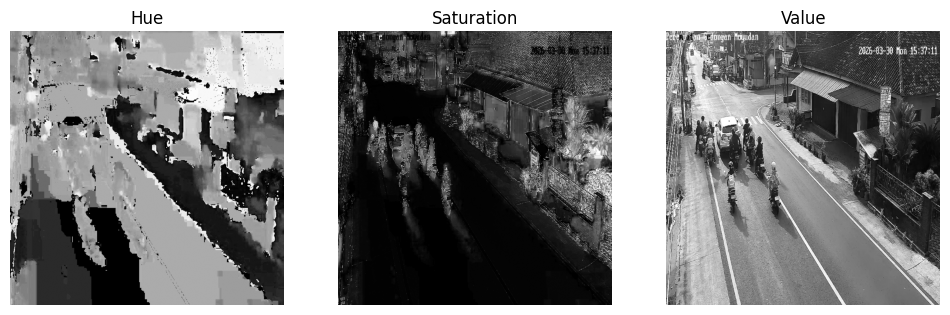

In [3]:
import cv2
import matplotlib.pyplot as plt

# Baca gambar
img = cv2.imread("frame_resized_768.jpg")

# Resize (opsional)
img = cv2.resize(img, (768, 768))

# Convert ke HSV
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# Convert BGR → RGB biar tampilannya benar
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
hsv_rgb = cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)

# Tampilkan di notebook
plt.figure(figsize=(10,5))

import cv2
import matplotlib.pyplot as plt

# Baca gambar
img = cv2.imread("frame_resized_768.jpg")

# Resize (opsional)
img = cv2.resize(img, (768, 768))

# Convert ke HSV
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

h, s, v = cv2.split(hsv)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Hue")
plt.imshow(h, cmap='gray')
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Saturation")
plt.imshow(s, cmap='gray')
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Value")
plt.imshow(v, cmap='gray')
plt.axis("off")

plt.show()

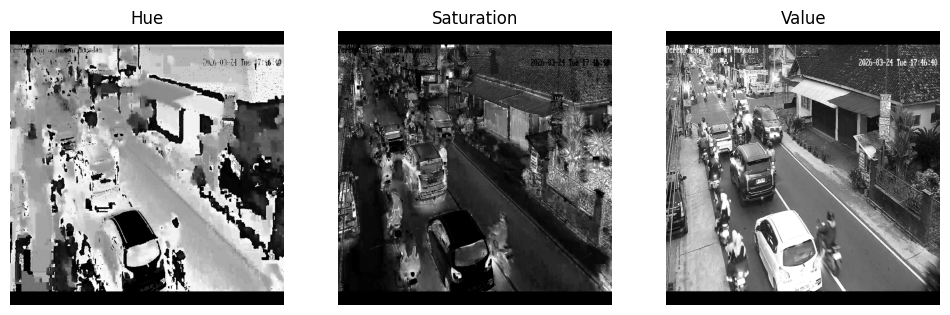

In [5]:
import cv2
import matplotlib.pyplot as plt

# Baca gambar
img = cv2.imread("image_2.png")

# Resize (opsional)
img = cv2.resize(img, (768, 768))

# Convert ke HSV
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

h, s, v = cv2.split(hsv)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Hue")
plt.imshow(h, cmap='gray')
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Saturation")
plt.imshow(s, cmap='gray')
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Value")
plt.imshow(v, cmap='gray')
plt.axis("off")

plt.show()

Select a ROI and then press SPACE or ENTER button!
Cancel the selection process by pressing c button!


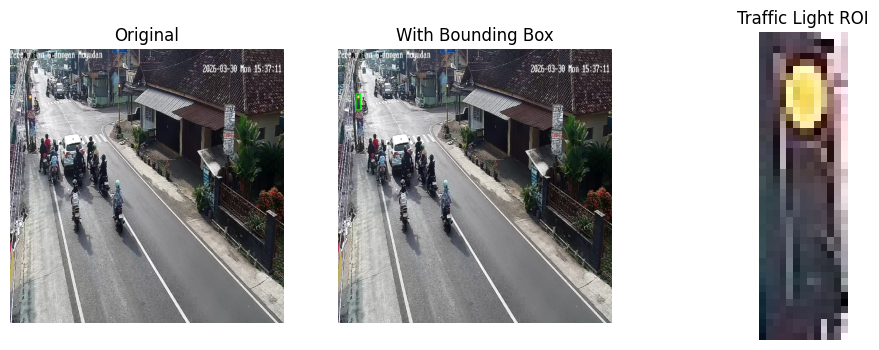

Bounding Box: x=50, y=125, w=13, h=45


In [3]:
import cv2
import matplotlib.pyplot as plt

# Baca gambar
img = cv2.imread("frame_resized_768.jpg")
img = cv2.resize(img, (768, 768))

# Pilih ROI (GUI tetap pakai OpenCV)
bbox = cv2.selectROI("Select Traffic Light ROI", img, fromCenter=False, showCrosshair=True)
cv2.destroyAllWindows()

# Ambil koordinat
x, y, w, h = bbox
roi = img[int(y):int(y+h), int(x):int(x+w)]

# Gambar bounding box di image
img_box = img.copy()
cv2.rectangle(img_box, (int(x), int(y)), (int(x+w), int(y+h)), (0, 255, 0), 2)

# Convert ke RGB untuk matplotlib
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_box_rgb = cv2.cvtColor(img_box, cv2.COLOR_BGR2RGB)
roi_rgb = cv2.cvtColor(roi, cv2.COLOR_BGR2RGB)

# ===== DISPLAY =====
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(img_rgb)
plt.axis("off")

plt.subplot(1,3,2)
plt.title("With Bounding Box")
plt.imshow(img_box_rgb)
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Traffic Light ROI")
plt.imshow(roi_rgb)
plt.axis("off")

plt.show()

# Simpan juga kalau mau
cv2.imwrite("traffic_light_roi.jpg", roi)
cv2.imwrite("image_with_bbox.jpg", img_box)

print(f"Bounding Box: x={x}, y={y}, w={w}, h={h}")